<a href="https://colab.research.google.com/github/AMXANASHRAF/cats-and-dogs-classification/blob/main/Dog_vs_Cat_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracting Dataset using Kaggle API

In [1]:
# installing the Kaggle library
!pip install kaggle

Importing the Dog vs Cat Dataset from Kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [4]:
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
 97% 1.03G/1.06G [00:11<00:00, 82.7MB/s]
100% 1.06G/1.06G [00:11<00:00, 98.1MB/s]


In [6]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import saving
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten, Dropout, BatchNormalization
from keras import Sequential
from keras.preprocessing.image import array_to_img, img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
import os
import PIL


In [15]:
#Generate
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [16]:
class_names = train_ds.class_names
print(class_names)
filepaths = list(train_ds.file_paths)
print(filepaths)


['cats', 'dogs']
['/content/train/cats/cat.7668.jpg', '/content/train/cats/cat.1568.jpg', '/content/train/dogs/dog.5989.jpg', '/content/train/dogs/dog.4023.jpg', '/content/train/cats/cat.738.jpg', '/content/train/cats/cat.1060.jpg', '/content/train/dogs/dog.6161.jpg', '/content/train/dogs/dog.6094.jpg', '/content/train/cats/cat.8035.jpg', '/content/train/cats/cat.8806.jpg', '/content/train/dogs/dog.3543.jpg', '/content/train/dogs/dog.2172.jpg', '/content/train/dogs/dog.7690.jpg', '/content/train/dogs/dog.3858.jpg', '/content/train/cats/cat.6724.jpg', '/content/train/dogs/dog.1224.jpg', '/content/train/dogs/dog.10590.jpg', '/content/train/dogs/dog.3180.jpg', '/content/train/cats/cat.10609.jpg', '/content/train/cats/cat.153.jpg', '/content/train/cats/cat.5805.jpg', '/content/train/dogs/dog.831.jpg', '/content/train/cats/cat.11964.jpg', '/content/train/cats/cat.30.jpg', '/content/train/dogs/dog.8473.jpg', '/content/train/cats/cat.2124.jpg', '/content/train/cats/cat.2388.jpg', '/content/tr

In [19]:
#Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [32]:
# Create CNN model

model = Sequential()

# Convolutional Block 1
model.add(Conv2D(16, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Convolutional Block 2
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Convolutional Block 3
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [33]:
class_labels = ['cats', 'dogs']
def convert_to_categorical_labels(y_pred):
    return [class_labels[i] for i in np.argmax(y_pred, axis=1)]

In [34]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,712,609 (14.16 MB)

 Trainable params: 3,712,385 (14.16 MB)

 Non-trainable params: 224 (896.00 B)

In [35]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [36]:
history = model.fit(train_ds,epochs=6,validation_data=validation_ds)

Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.5749 - loss: 1.0395 - val_accuracy: 0.4742 - val_loss: 0.9698
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step - accuracy: 0.7163 - loss: 0.5617 - val_accuracy: 0.7118 - val_loss: 0.6227
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.7819 - loss: 0.4560 - val_accuracy: 0.7726 - val_loss: 0.5648
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8384 - loss: 0.3607 - val_accuracy: 0.7624 - val_loss: 0.5409
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.8801 - loss: 0.2855 - val_accuracy: 0.7760 - val_loss: 0.8374
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step - accuracy: 0.9249 - loss: 0.1880 - val_accuracy: 0.7514 - val_loss: 1.2031


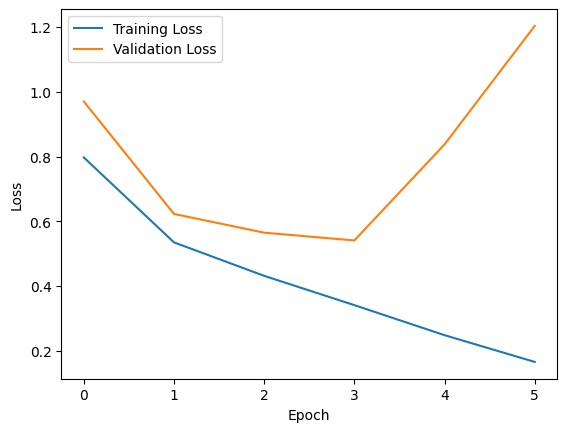

In [37]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

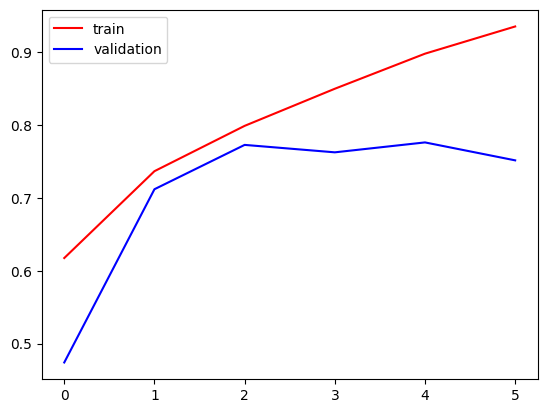

In [38]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [39]:
model.save('cats_and_dogs_classifier.h5')

In [40]:
import cv2

In [67]:
test_img = cv2.imread('/content/istockphoto-1443562748-612x612.jpg')

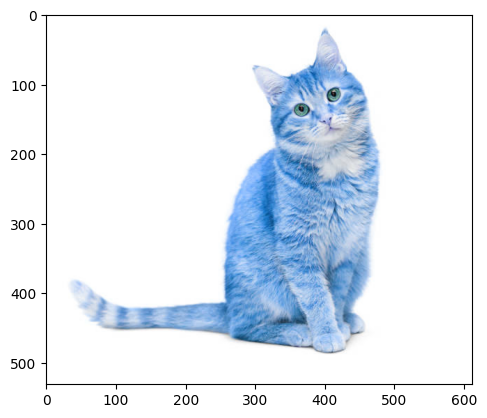

In [68]:
import matplotlib.pyplot as plt

if test_img is not None:
    plt.imshow(test_img)
    plt.show()
else:
    print("Error loading image. Please check the image path.")

In [69]:
test_img.shape

(531, 612, 3)

In [70]:
test_img = cv2.resize(test_img,(256,256))

In [71]:
test_input = test_img.reshape((1,256,256,3))

In [75]:
y_pred = model.predict(test_input)
if y_pred == 1:
    print("It's a Dog")
else:
    print("It's a Cat")
print(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
It's a Cat
[[0.]]
